# Detecting COVID-19 with Chest X Ray using PyTorch

Image classification of Chest X Rays in one of three classes: Normal, Viral Pneumonia, COVID-19



Dataset from [COVID-19 Radiography Dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database) on Kaggle

In [46]:
!git clone https://github.com/Shivam6035/Bio-informatics

Cloning into 'Bio-informatics'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 80.77 KiB | 1.97 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once your Drive is mounted, you can access files. For example, if you have a file named `my_data.csv` in your Drive's root, you can access it like this:

Remember to replace `my_data.csv` with the actual path and name of your file in Google Drive. If your file is in a folder (e.g., `MyFolder`), the path would be `/content/drive/MyDrive/MyFolder/my_data.csv`.

# Importing Libraries

In [1]:
%matplotlib inline

import os
import shutil
import random
import torch
import torchvision
import numpy as np

from PIL import Image
from matplotlib import pyplot as plt

torch.manual_seed(0)

print('Using PyTorch version', torch.__version__)

Using PyTorch version 2.10.0+cpu


# Preparing Training and Test Sets

In [35]:
class_names = ['normal', 'viral', 'covid']
kaggle_download_path = path # This is /kaggle/input/covid19-radiography-database
actual_dataset_root_in_kaggle = os.path.join(kaggle_download_path, 'COVID-19_Radiography_Dataset') # Corrected based on debug output

# Define a writable directory where we will process the data
processed_data_root = '/content/COVID-19-Radiography-Database-Processed' # Corrected to be the base directory

# Set root_dir for subsequent operations to the writable, processed path
root_dir = processed_data_root
source_dirs = ['Normal', 'Viral Pneumonia', 'COVID'] # Corrected source directory names

print(f"Processing dataset from {actual_dataset_root_in_kaggle} to {root_dir}")

# Clean up previous processed data if it exists and create new ones
if os.path.exists(root_dir):
    shutil.rmtree(root_dir)
os.makedirs(root_dir)

# Copy initial raw directories from Kaggle path to writable processed_data_root
for d in source_dirs:
    source_path = os.path.join(actual_dataset_root_in_kaggle, d)
    target_path = os.path.join(root_dir, d)
    if os.path.exists(source_path):
        shutil.copytree(source_path, target_path)
    else:
        print(f"Warning: Source directory {source_path} not found during initial copy.")

# Now, proceed with renaming and creating test set using the writable root_dir
# We check if the expected structure exists *after* copying
if os.path.isdir(os.path.join(root_dir, source_dirs[1])): # Check for 'Viral Pneumonia' as an example
    print("Restructuring dataset...")
    # Create 'test' directory
    os.mkdir(os.path.join(root_dir, 'test'))

    # Rename original folders (Normal, Viral Pneumonia, COVID) to (normal, viral, covid)
    for i, d in enumerate(source_dirs):
        original_path = os.path.join(root_dir, d)
        new_path = os.path.join(root_dir, class_names[i])
        if os.path.exists(original_path):
            os.rename(original_path, new_path)
        else:
            print(f"Warning: Directory to rename {original_path} not found.")

    # Create subdirectories inside 'test'
    for c in class_names:
        os.mkdir(os.path.join(root_dir, 'test', c))

    # Move selected images to 'test' subdirectories
    for c in class_names:
        class_folder_path = os.path.join(root_dir, c)
        if os.path.isdir(class_folder_path):
            images = [x for x in os.listdir(class_folder_path) if x.lower().endswith('png')]
            # Ensure we don't try to sample more than available images
            num_samples = min(30, len(images))
            selected_images = random.sample(images, num_samples)
            for image in selected_images:
                source_img_path = os.path.join(class_folder_path, image)
                target_img_path = os.path.join(root_dir, 'test', c, image)
                shutil.move(source_img_path, target_img_path)
        else:
            print(f"Warning: Class folder {class_folder_path} not found for moving images.")
else:
    print(f"Initial dataset structure from Kaggle not found at {actual_dataset_root_in_kaggle}. Unable to restructure.")


Processing dataset from /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset to /content/COVID-19-Radiography-Database-Processed
Restructuring dataset...


# Creating Custom Dataset

In [47]:
class ChestXRayDataset(torch.utils.data.Dataset):
    def __init__(self, image_dirs, transform):
        def get_images(class_name):
            # Modify to look inside 'images' subfolder
            class_path = image_dirs[class_name]
            images_subfolder_path = os.path.join(class_path, 'images')
            if os.path.exists(images_subfolder_path):
                images = [x for x in os.listdir(images_subfolder_path) if x[-3:].lower().endswith('png')]
            else:
                # Fallback if no 'images' subfolder (though likely one exists)
                images = [x for x in os.listdir(class_path) if x[-3:].lower().endswith('png')]
            print(f'Found {len(images)} {class_name} examples')
            return images

        self.images = {}
        self.class_names = ['normal', 'viral', 'covid']

        for class_name in self.class_names:
            self.images[class_name] = get_images(class_name)

        self.image_dirs = image_dirs
        self.transform = transform


    def __len__(self):
        return sum([len(self.images[class_name]) for class_name in self.class_names])


    def __getitem__(self, index):
        class_name = random.choice(self.class_names)
        # Ensure index is within bounds of the selected class's images
        if not self.images[class_name]: # If no images for this class, choose another
            while not self.images[class_name]:
                class_name = random.choice(self.class_names)
        index = index % len(self.images[class_name])

        image_name = self.images[class_name][index]

        # Correct path to include 'images' subfolder
        image_path = os.path.join(self.image_dirs[class_name], 'images', image_name)
        if not os.path.exists(image_path): # Fallback if image not in 'images' subfolder
            image_path = os.path.join(self.image_dirs[class_name], image_name)

        image = Image.open(image_path).convert('RGB')
        return self.transform(image), self.class_names.index(class_name)

# Image Transformations

In [48]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(224, 224)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [55]:
class_names = train_dataset.class_names

def show_images(images, labels, preds):
    plt.figure(figsize=(8, 4))
    for i, image in enumerate(images):
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        image = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = image * std + mean
        image = np.clip(image, 0., 1.)
        plt.imshow(image)
        col = 'green'
        if preds[i] != labels[i]:
            col = 'red'

        plt.xlabel(f'{class_names[int(labels[i].numpy())]}')
        plt.ylabel(f'{class_names[int(preds[i].numpy())]}', color=col)
    plt.tight_layout()
    plt.show()

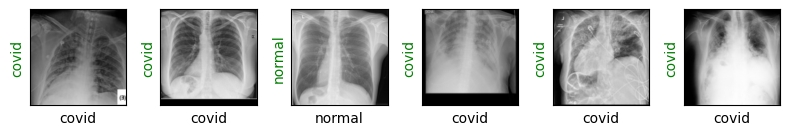

In [56]:
images, labels = next(iter(dl_train))
show_images(images, labels, labels)

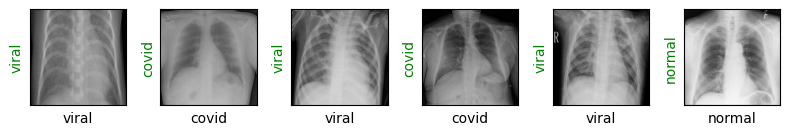

In [57]:
images, labels = next(iter(dl_test))
show_images(images, labels, labels)

In [78]:
def train(epochs):
    print('Starting training..')
    history_data = {
        'train_loss_epoch': [],
        'val_loss_steps': [],
        'val_accuracy_steps': []
    }
    val_steps_recorded = []

    for e in range(0, epochs):
        print('='*20)
        print(f'Starting epoch {e + 1}/{epochs}')
        print('='*20)

        train_loss = 0.
        val_loss_current_epoch = 0.
        num_val_steps_in_epoch = 0

        resnet18.train() # set model to training phase

        for train_step, (images, labels) in enumerate(dl_train):
            optimizer.zero_grad()
            outputs = resnet18(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            if train_step % 20 == 0: # Evaluate every 20 steps
                print('Evaluating at step', train_step)
                val_steps_recorded.append(e * len(dl_train) + train_step)

                accuracy = 0
                resnet18.eval() # set model to eval phase

                current_val_loss_batch = 0
                current_val_accuracy_batch = 0
                num_val_batches = 0

                with torch.no_grad(): # Disable gradient calculation for validation
                    for val_step_in_batch, (images_val, labels_val) in enumerate(dl_test):
                        outputs_val = resnet18(images_val)
                        loss_val = loss_fn(outputs_val, labels_val)
                        current_val_loss_batch += loss_val.item()

                        _, preds_val = torch.max(outputs_val, 1)
                        current_val_accuracy_batch += sum((preds_val == labels_val).numpy())
                        num_val_batches += 1

                avg_val_loss = current_val_loss_batch / num_val_batches if num_val_batches > 0 else 0
                avg_val_accuracy = current_val_accuracy_batch / len(test_dataset)

                history_data['val_loss_steps'].append(avg_val_loss)
                history_data['val_accuracy_steps'].append(avg_val_accuracy)

                print(f'Validation Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_accuracy:.4f}')

                show_preds()

                resnet18.train() # set model back to training phase

                if avg_val_accuracy >= 0.95:
                    print('Performance condition satisfied, stopping..')
                    return history_data, val_steps_recorded

        train_loss /= (train_step + 1)
        history_data['train_loss_epoch'].append(train_loss)

        print(f'Training Loss: {train_loss:.4f}')
    print('Training complete..')
    return history_data, val_steps_recorded

Starting training..
Starting epoch 1/1
Evaluating at step 0
Validation Loss: 1.3503, Accuracy: 0.3667


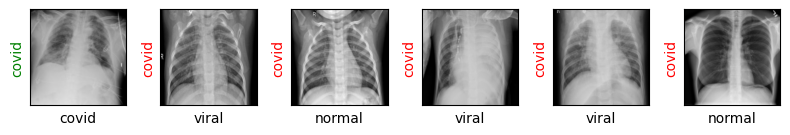

Evaluating at step 20
Validation Loss: 0.7592, Accuracy: 0.6889


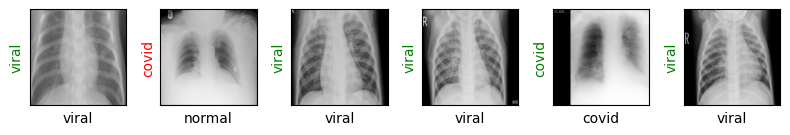

Evaluating at step 40
Validation Loss: 0.4831, Accuracy: 0.8667


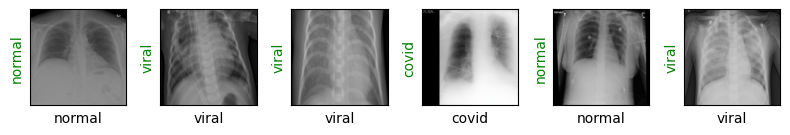

Evaluating at step 60
Validation Loss: 0.3561, Accuracy: 0.8667


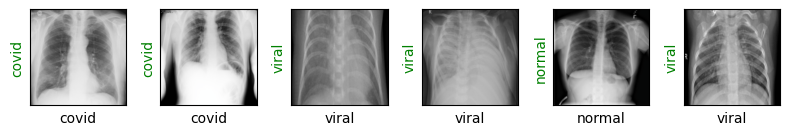

Evaluating at step 80
Validation Loss: 0.2585, Accuracy: 0.8556


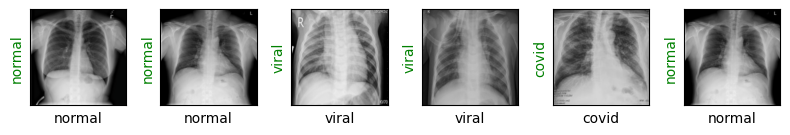

Evaluating at step 100
Validation Loss: 0.1711, Accuracy: 0.9667


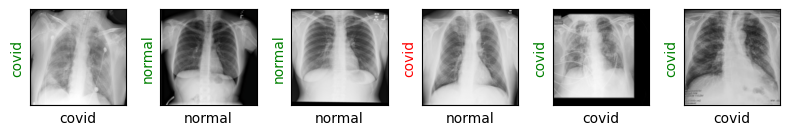

Performance condition satisfied, stopping..
CPU times: user 3min 42s, sys: 1.94 s, total: 3min 44s
Wall time: 3min 47s


In [79]:
%%time

history_data, val_steps = train(epochs=1)

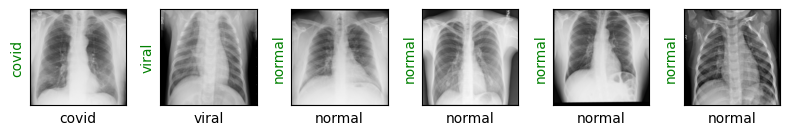

In [64]:
show_preds()

In [65]:
resnet18 = torchvision.models.resnet18(pretrained=True)

print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [66]:
resnet18.fc = torch.nn.Linear(in_features=512, out_features=3)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=3e-5)

In [67]:
def show_preds():
    resnet18.eval()
    images, labels = next(iter(dl_test))
    outputs = resnet18(images)
    _, preds = torch.max(outputs, 1)
    show_images(images, labels, preds)

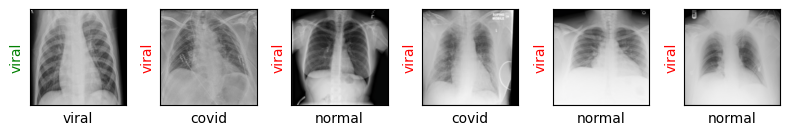

In [68]:
show_preds()

## Fine tune

In [69]:
def train(epochs):
    print('Starting training..')
    for e in range(0, epochs):
        print('='*20)
        print(f'Starting epoch {e + 1}/{epochs}')
        print('='*20)

        train_loss = 0.
        val_loss = 0.

        resnet18.train() # set model to training phase

        for train_step, (images, labels) in enumerate(dl_train):
            optimizer.zero_grad()
            outputs = resnet18(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            if train_step % 20 == 0:
                print('Evaluating at step', train_step)

                accuracy = 0

                resnet18.eval() # set model to eval phase

                for val_step, (images, labels) in enumerate(dl_test):
                    outputs = resnet18(images)
                    loss = loss_fn(outputs, labels)
                    val_loss += loss.item()

                    _, preds = torch.max(outputs, 1)
                    accuracy += sum((preds == labels).numpy())

                val_loss /= (val_step + 1)
                accuracy = accuracy/len(test_dataset)
                print(f'Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}')

                show_preds()

                resnet18.train()

                if accuracy >= 0.95:
                    print('Performance condition satisfied, stopping..')
                    return

        train_loss /= (train_step + 1)

        print(f'Training Loss: {train_loss:.4f}')
    print('Training complete..')

Starting training..
Starting epoch 1/1
Evaluating at step 0
Validation Loss: 1.4027, Accuracy: 0.3333


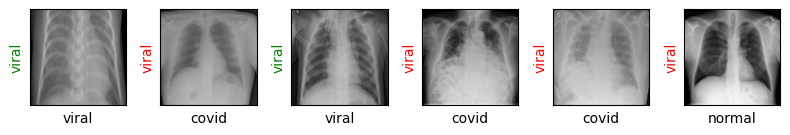

Evaluating at step 20
Validation Loss: 1.0385, Accuracy: 0.5667


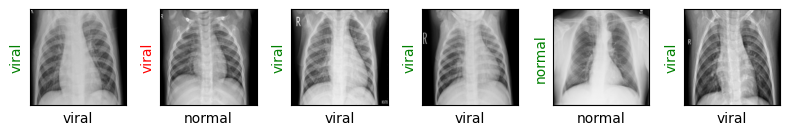

Evaluating at step 40
Validation Loss: 0.6559, Accuracy: 0.7778


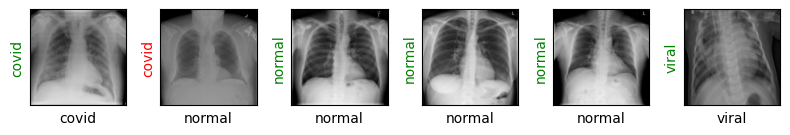

Evaluating at step 60
Validation Loss: 0.4075, Accuracy: 0.8667


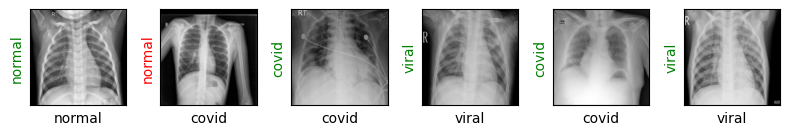

Evaluating at step 80
Validation Loss: 0.2965, Accuracy: 0.8778


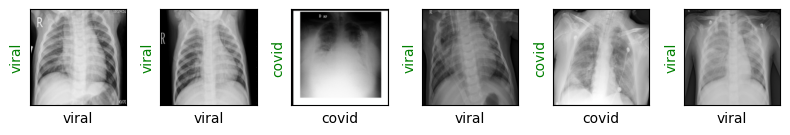

Evaluating at step 100
Validation Loss: 0.2549, Accuracy: 0.9222


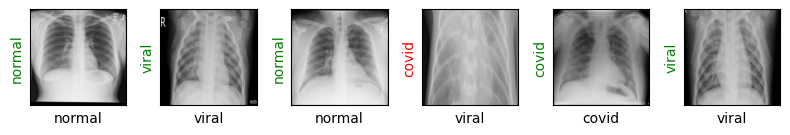

Evaluating at step 120
Validation Loss: 0.2507, Accuracy: 0.9222


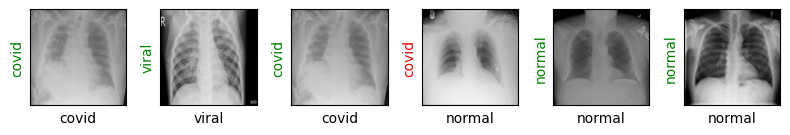

Evaluating at step 140
Validation Loss: 0.2785, Accuracy: 0.8889


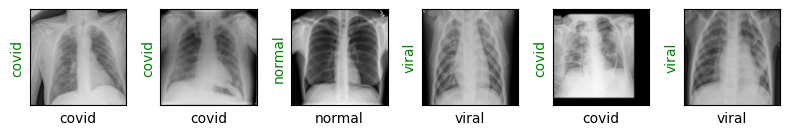

Evaluating at step 160
Validation Loss: 0.2970, Accuracy: 0.9111


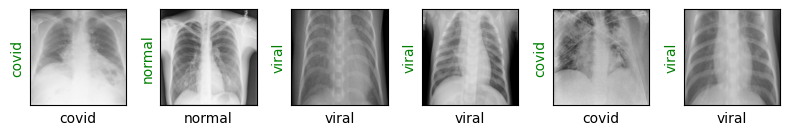

Evaluating at step 180
Validation Loss: 0.3116, Accuracy: 0.8556


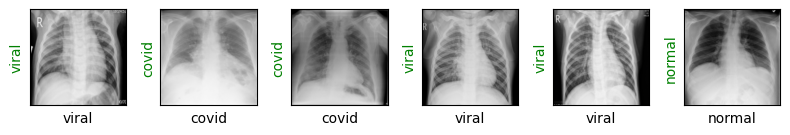

Evaluating at step 200
Validation Loss: 0.1773, Accuracy: 0.9000


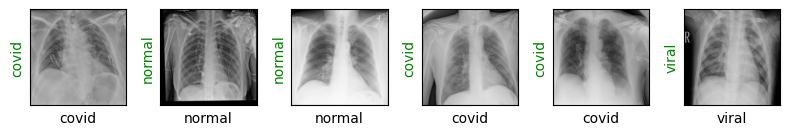

Evaluating at step 220
Validation Loss: 0.2204, Accuracy: 0.8889


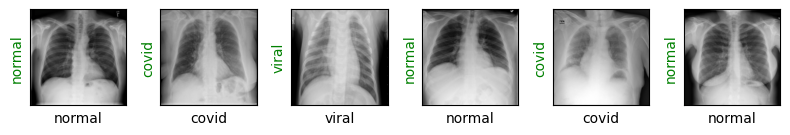

Evaluating at step 240
Validation Loss: 0.2008, Accuracy: 0.9111


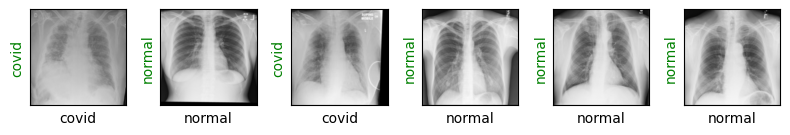

Evaluating at step 260
Validation Loss: 0.1605, Accuracy: 0.9444


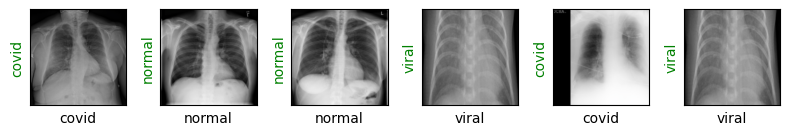

Evaluating at step 280
Validation Loss: 0.1798, Accuracy: 0.9444


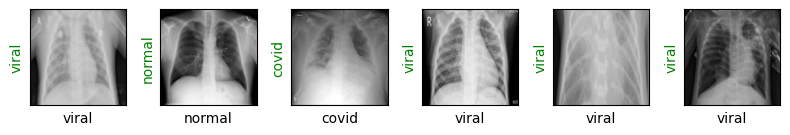

Evaluating at step 300
Validation Loss: 0.0967, Accuracy: 0.9778


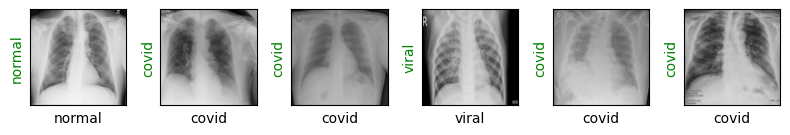

Performance condition satisfied, stopping..
CPU times: user 10min 47s, sys: 8.68 s, total: 10min 56s
Wall time: 11min 2s


In [70]:
%%time

train(epochs=1)

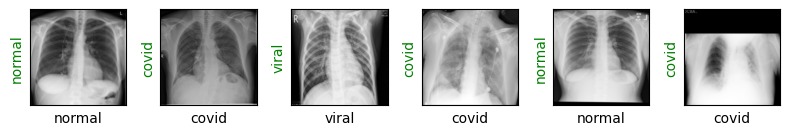

In [71]:
show_preds()

In [76]:
class ChestXRayDataset(torch.utils.data.Dataset):
    def __init__(self, image_dirs, transform):
        def get_images(class_name):
            # Modify to look inside 'images' subfolder
            class_path = image_dirs[class_name]
            images_subfolder_path = os.path.join(class_path, 'images')
            if os.path.exists(images_subfolder_path):
                images = [x for x in os.listdir(images_subfolder_path) if x[-3:].lower().endswith('png')]
            else:
                # Fallback if no 'images' subfolder (though likely one exists)
                images = [x for x in os.listdir(class_path) if x[-3:].lower().endswith('png')]
            print(f'Found {len(images)} {class_name} examples')
            return images

        self.images = {}
        self.class_names = ['normal', 'viral', 'covid']

        for class_name in self.class_names:
            self.images[class_name] = get_images(class_name)

        self.image_dirs = image_dirs
        self.transform = transform


    def __len__(self):
        return sum([len(self.images[class_name]) for class_name in self.class_names])


    def __getitem__(self, index):
        class_name = random.choice(self.class_names)
        # Ensure index is within bounds of the selected class's images
        if not self.images[class_name]: # If no images for this class, choose another
            # This can happen if all images for a chosen class are moved
            # Or if a class was empty to begin with.
            # We need to ensure we pick a class that has images.
            available_classes = [cn for cn in self.class_names if self.images[cn]]
            if not available_classes:
                raise RuntimeError("No images found in any class directories.")
            class_name = random.choice(available_classes)

        index = index % len(self.images[class_name])

        image_name = self.images[class_name][index]

        # Correct path to include 'images' subfolder
        image_path = os.path.join(self.image_dirs[class_name], 'images', image_name)
        if not os.path.exists(image_path): # Fallback if image not in 'images' subfolder
            image_path = os.path.join(self.image_dirs[class_name], image_name)

        image = Image.open(image_path).convert('RGB')
        return self.transform(image), self.class_names.index(class_name)

# Data Visualization

In [ ]:
class_names = train_dataset.class_names


def show_images(images, labels, preds):
    plt.figure(figsize=(8, 4))
    for i, image in enumerate(images):
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        image = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = image * std + mean
        image = np.clip(image, 0., 1.)
        plt.imshow(image)
        col = 'green'
        if preds[i] != labels[i]:
            col = 'red'

        plt.xlabel(f'{class_names[int(labels[i].numpy())]}')
        plt.ylabel(f'{class_names[int(preds[i].numpy())]}', color=col)
    plt.tight_layout()
    plt.show()

In [ ]:
images, labels = next(iter(dl_train))
show_images(images, labels, labels)

In [ ]:
images, labels = next(iter(dl_test))
show_images(images, labels, labels)

In [73]:
resnet18.fc = torch.nn.Linear(in_features=512, out_features=3)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=3e-5)

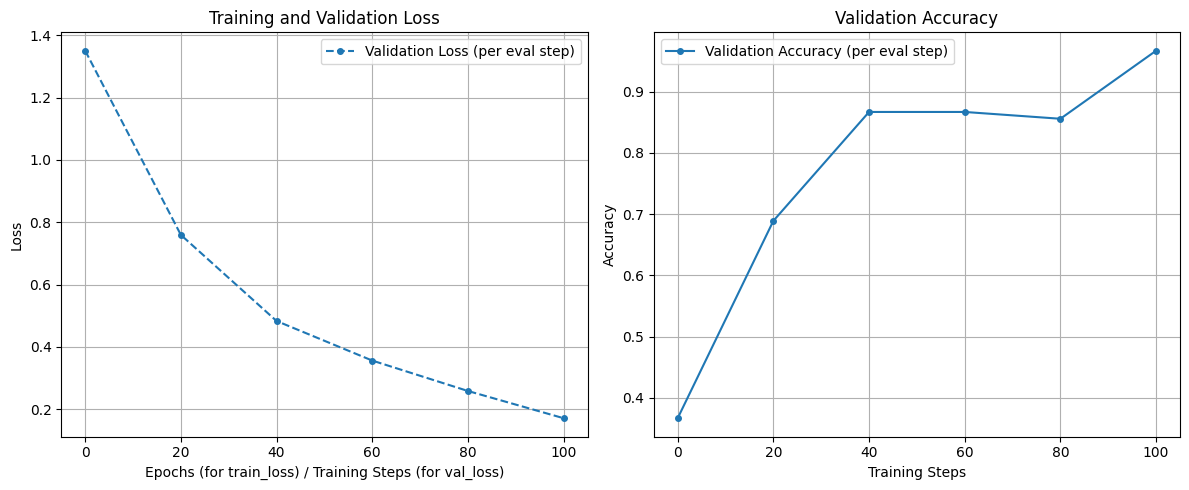

In [80]:
import matplotlib.pyplot as plt

# Example plotting code (assuming history_data and val_steps are available)
if 'history_data' in locals() and 'val_steps' in locals():
    plt.figure(figsize=(12, 5))

    # Plotting the training and validation loss
    plt.subplot(1, 2, 1)
    if history_data['train_loss_epoch']:
        plt.plot(range(1, len(history_data['train_loss_epoch']) + 1), history_data['train_loss_epoch'], label='Training Loss (per epoch)')
    if history_data['val_loss_steps']:
        plt.plot(val_steps, history_data['val_loss_steps'], label='Validation Loss (per eval step)', marker='o', markersize=4, linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs (for train_loss) / Training Steps (for val_loss)')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plotting the validation accuracy
    plt.subplot(1, 2, 2)
    if history_data['val_accuracy_steps']:
        plt.plot(val_steps, history_data['val_accuracy_steps'], label='Validation Accuracy (per eval step)', marker='o', markersize=4, linestyle='-')
    plt.title('Validation Accuracy')
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Training history (history_data, val_steps) not found. Please ensure the train function is modified to return it and re-run training.")

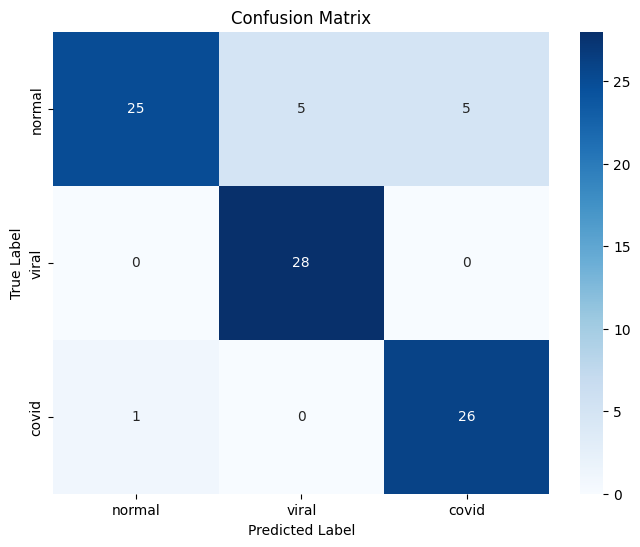

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set the model to evaluation mode
resnet18.eval()

all_preds = []
all_labels = []

# Iterate over the test dataset to get all predictions and labels
with torch.no_grad():
    for images, labels in dl_test:
        outputs = resnet18(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()